<a href="https://colab.research.google.com/github/fanxu30/XAI/blob/main/adversarial_patch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda:0
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to ./saved_models/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 150MB/s]


=== Band Logo Adversarial Patch Creation ===
Creative Component: Disguising adversarial patch as a rock band logo
Target class: electric guitar
Patch size: 64x64

Training the band logo patch...
Training band logo patch for class: electric guitar (index: 546)


Epoch 1/8:   0%|          | 0/281 [00:00<?, ?it/s]

Epoch 1, Average Loss: 0.6623


...

Epoch 7, Average Loss: 0.1010


Epoch 8/8:   0%|          | 0/281 [00:00<?, ?it/s]

Epoch 8, Average Loss: 0.1084

Evaluating patch performance...


Evaluating patch:   0%|          | 0/157 [00:00<?, ?it/s]

Patch success rate for 'electric guitar': 97.13%

Visualizing the patch...


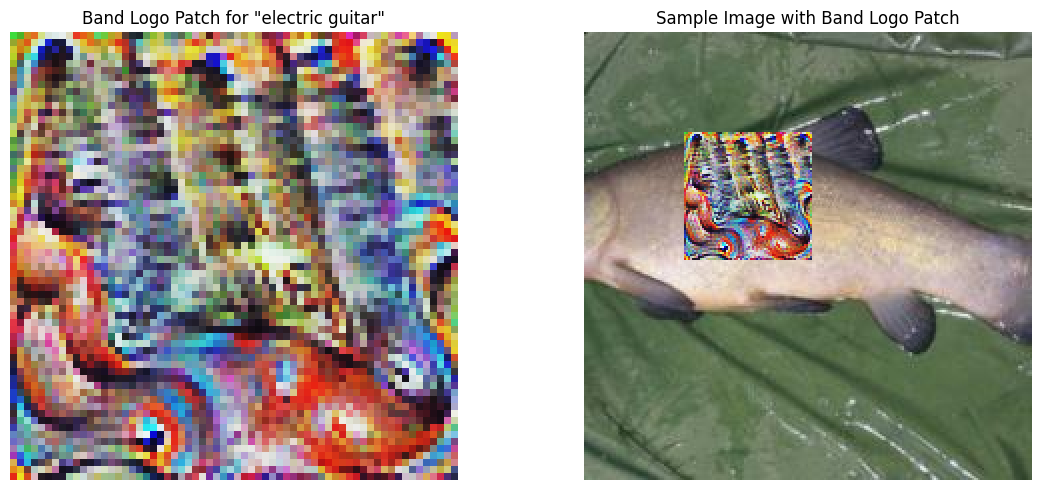


Saving patch for physical testing...


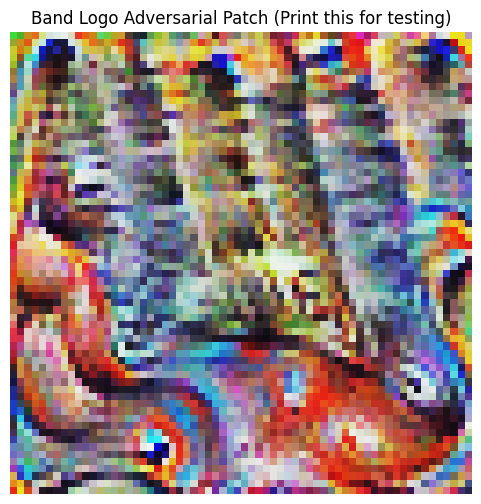

Patch saved as my_band_logo_patch.png
Print this image and bring it to class for testing!


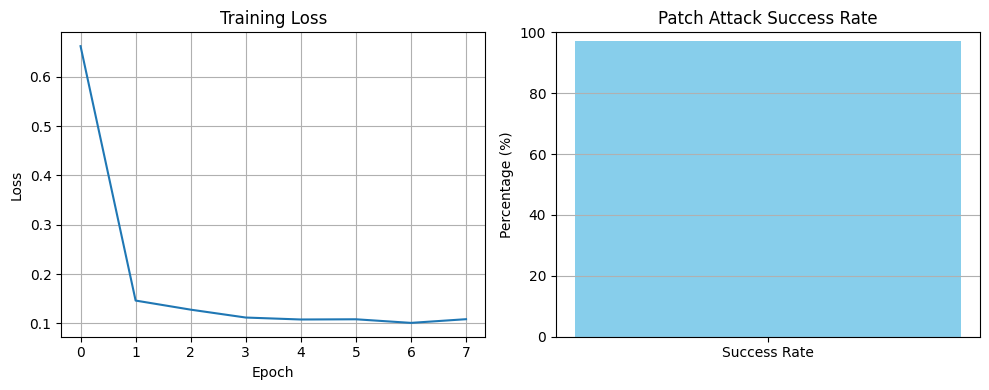


=== Results Summary ===
Target class: electric guitar
Final success rate: 97.13%
Physical patch saved as 'my_band_logo_patch.png'
Bring the printed patch to class for live testing!


In [1]:
# Adversarial Patch Assignment
# This notebook creates an adversarial patch disguised as a "band logo sticker"

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.utils.data as data
import torch.optim as optim
import torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms
import urllib.request
import zipfile

# Set up device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Set up paths
DATASET_PATH = "./data"
CHECKPOINT_PATH = "./saved_models"
os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# Load pretrained ResNet34 model
os.environ["TORCH_HOME"] = CHECKPOINT_PATH
pretrained_model = torchvision.models.resnet34(weights='IMAGENET1K_V1')
pretrained_model = pretrained_model.to(device)
pretrained_model.eval()
for p in pretrained_model.parameters():
    p.requires_grad = False

# ImageNet normalization
NORM_MEAN = np.array([0.485, 0.456, 0.406])
NORM_STD = np.array([0.229, 0.224, 0.225])
TENSOR_MEANS, TENSOR_STD = torch.FloatTensor(NORM_MEAN)[:,None,None], torch.FloatTensor(NORM_STD)[:,None,None]

# Load dataset (using the same setup as template)
plain_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

# Download dataset if not exists
dataset_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial10/TinyImageNet.zip"
dataset_path = os.path.join(DATASET_PATH, "TinyImageNet.zip")
if not os.path.exists(os.path.join(DATASET_PATH, "TinyImageNet")):
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, dataset_path)
    with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
        zip_ref.extractall(DATASET_PATH)

imagenet_path = os.path.join(DATASET_PATH, "TinyImageNet/")
dataset = ImageFolder(root=imagenet_path, transform=plain_transforms)
data_loader = data.DataLoader(dataset, batch_size=32, shuffle=False, drop_last=False, num_workers=2)

# Load label names
with open(os.path.join(imagenet_path, "label_list.json"), "r") as f:
    label_names = json.load(f)

def get_label_index(lab_str):
    return label_names.index(lab_str)

# Creative Component: "Band Logo" Disguised Patch
# We'll create a patch that looks like a rock band logo but actually makes the model predict "electric guitar"

class BandLogoPatch:
    def __init__(self, patch_size=64):
        self.patch_size = patch_size
        self.base_patch = None

    def create_band_logo_design(self):
        """Create a band logo style initial design"""
        # Start with a base that looks like a typical rock band logo
        patch = torch.zeros(3, self.patch_size, self.patch_size)

        # Add some stylized text-like patterns (simulating a band name)
        center = self.patch_size // 2
        for i in range(3):  # RGB channels
            # Create angular, aggressive shapes typical of metal band logos
            for angle in range(0, 360, 30):
                rad = angle * np.pi / 180
                x = int(center + (center-5) * np.cos(rad))
                y = int(center + (center-5) * np.sin(rad))
                if 0 <= x < self.patch_size and 0 <= y < self.patch_size:
                    patch[i, x:x+3, y:y+3] = 0.8

            # Add some "spikes" around edges
            for j in range(0, self.patch_size, 5):
                patch[i, j:j+2, 0:2] = 0.6
                patch[i, j:j+2, self.patch_size-2:self.patch_size] = 0.6
                patch[i, 0:2, j:j+2] = 0.6
                patch[i, self.patch_size-2:self.patch_size, j:j+2] = 0.6

        return patch

    def initialize_patch(self):
        """Initialize patch with band logo design"""
        self.base_patch = nn.Parameter(self.create_band_logo_design(), requires_grad=True)
        return self.base_patch

def patch_forward(patch):
    """Convert patch parameters to valid image values"""
    patch = (torch.tanh(patch) + 1 - 2 * TENSOR_MEANS) / (2 * TENSOR_STD)
    return patch

def place_patch(img, patch, position=None):
    """Place patch on image at random position"""
    batch_size = img.shape[0]
    patched_imgs = img.clone()

    for i in range(batch_size):
        if position is None:
            # Random position
            h_offset = np.random.randint(0, img.shape[2] - patch.shape[1] - 1)
            w_offset = np.random.randint(0, img.shape[3] - patch.shape[2] - 1)
        else:
            h_offset, w_offset = position

        patched_imgs[i, :, h_offset:h_offset+patch.shape[1], w_offset:w_offset+patch.shape[2]] = patch_forward(patch)

    return patched_imgs

def train_band_logo_patch(target_class="electric guitar", patch_size=64, num_epochs=8):
    """Train a band logo disguised adversarial patch"""

    target_idx = get_label_index(target_class)
    print(f"Training band logo patch for class: {target_class} (index: {target_idx})")

    # Initialize band logo patch
    band_logo = BandLogoPatch(patch_size)
    patch = band_logo.initialize_patch()

    # Split dataset
    train_set, val_set = torch.utils.data.random_split(dataset, [4500, 500])
    train_loader = data.DataLoader(train_set, batch_size=16, shuffle=True, drop_last=True)

    # Optimizer - using Adam for better convergence
    optimizer = torch.optim.Adam([patch], lr=0.1, weight_decay=1e-4)
    loss_module = nn.CrossEntropyLoss()

    # Training loop
    losses = []
    for epoch in range(num_epochs):
        epoch_loss = 0
        for img, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
            # Place patch on images
            patched_imgs = place_patch(img, patch)
            patched_imgs = patched_imgs.to(device)

            # Get predictions
            pred = pretrained_model(patched_imgs)

            # Target all predictions to be the target class
            target_labels = torch.zeros(patched_imgs.shape[0], device=device, dtype=torch.long).fill_(target_idx)
            loss = loss_module(pred, target_labels)

            # Optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}, Average Loss: {avg_loss:.4f}")

    return patch.data, losses

def evaluate_patch(patch, target_class):
    """Evaluate patch performance"""
    target_idx = get_label_index(target_class)

    model = pretrained_model
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for img, labels in tqdm(data_loader, desc="Evaluating patch"):
            # Skip images that are already the target class
            mask = (labels != target_idx)
            if mask.sum() == 0:
                continue

            img = img[mask]
            labels = labels[mask]

            # Test patch at 4 different positions for robustness
            for _ in range(4):
                patched_imgs = place_patch(img, patch)
                patched_imgs = patched_imgs.to(device)

                pred = model(patched_imgs)
                predicted_classes = pred.argmax(dim=-1)

                correct += (predicted_classes.cpu() == target_idx).sum().item()
                total += len(img)

    accuracy = correct / total if total > 0 else 0
    print(f"Patch success rate for '{target_class}': {accuracy*100:.2f}%")
    return accuracy

def visualize_patch(patch, target_class):
    """Visualize the trained patch"""
    # Convert patch to displayable format
    patch_display = (torch.tanh(patch) + 1) / 2
    patch_display = patch_display.cpu().permute(1, 2, 0).detach().numpy()
    patch_display = np.clip(patch_display, 0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Show the patch
    axes[0].imshow(patch_display)
    axes[0].set_title(f'Band Logo Patch for "{target_class}"')
    axes[0].axis('off')

    # Show patch on sample image
    sample_img, _ = dataset[0]
    sample_with_patch = place_patch(sample_img.unsqueeze(0), patch, position=(50, 50))[0]

    # Denormalize for display
    sample_display = sample_with_patch.cpu() * torch.FloatTensor(NORM_STD)[:, None, None] + torch.FloatTensor(NORM_MEAN)[:, None, None]
    sample_display = sample_display.permute(1, 2, 0).numpy()
    sample_display = np.clip(sample_display, 0, 1)

    axes[1].imshow(sample_display)
    axes[1].set_title('Sample Image with Band Logo Patch')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    return patch_display

def save_patch_for_printing(patch, filename="band_logo_patch.png"):
    """Save patch as image for printing"""
    patch_display = (torch.tanh(patch) + 1) / 2
    patch_display = patch_display.cpu().permute(1, 2, 0).detach().numpy()
    patch_display = np.clip(patch_display, 0, 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(patch_display)
    plt.axis('off')
    plt.title('Band Logo Adversarial Patch (Print this for testing)')
    plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()

    print(f"Patch saved as {filename}")
    print("Print this image and bring it to class for testing!")

# Main execution
if __name__ == "__main__":
    # Choose target class - electric guitar fits the "band" theme
    TARGET_CLASS = "electric guitar"
    PATCH_SIZE = 64
    NUM_EPOCHS = 8

    print("=== Band Logo Adversarial Patch Creation ===")
    print("Creative Component: Disguising adversarial patch as a rock band logo")
    print(f"Target class: {TARGET_CLASS}")
    print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}")
    print()

    # Train the patch
    print("Training the band logo patch...")
    trained_patch, losses = train_band_logo_patch(
        target_class=TARGET_CLASS,
        patch_size=PATCH_SIZE,
        num_epochs=NUM_EPOCHS
    )

    # Evaluate the patch
    print("\nEvaluating patch performance...")
    accuracy = evaluate_patch(trained_patch, TARGET_CLASS)

    # Visualize results
    print("\nVisualizing the patch...")
    patch_image = visualize_patch(trained_patch, TARGET_CLASS)

    # Save patch for printing
    print("\nSaving patch for physical testing...")
    save_patch_for_printing(trained_patch, "my_band_logo_patch.png")

    # Plot training loss
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.bar(['Success Rate'], [accuracy * 100], color='skyblue')
    plt.ylabel('Percentage (%)')
    plt.title('Patch Attack Success Rate')
    plt.ylim(0, 100)
    plt.grid(True, axis='y')

    plt.tight_layout()
    plt.show()

    print(f"\n=== Results Summary ===")
    print(f"Target class: {TARGET_CLASS}")
    print(f"Final success rate: {accuracy*100:.2f}%")
    print("Physical patch saved as 'my_band_logo_patch.png'")
    print("Bring the printed patch to class for live testing!")